In [1]:
import tensorflow as tf
# More imports
from tensorflow.keras.layers import Input, Dense, Flatten
from tensorflow.keras.applications.vgg16 import VGG16 as PretrainedModel, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from glob import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

2026-02-02 06:56:29.358121: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-02 06:56:29.389109: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-02 06:56:30.213858: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# Data from: https://mmspg.epfl.ch/downloads/food-image-datasets/
# !wget --passive-ftp --prefer-family=ipv4 --ftp-user FoodImage@grebvm2.epfl.ch \
#  --ftp-password Cahc1moo -nc ftp://tremplin.epfl.ch/Food-5K.zip
!wget -nc https://archive.org/download/food-5-k/Food-5K.zip

File ‘Food-5K.zip’ already there; not retrieving.



In [3]:
!unzip -qq -o Food-5K.zip

In [4]:
!ls Food-5K/training

0_0.jpg     0_1387.jpg	0_422.jpg  0_809.jpg   1_1195.jpg  1_230.jpg  1_617.jpg
0_1000.jpg  0_1388.jpg	0_423.jpg  0_80.jpg    1_1196.jpg  1_231.jpg  1_618.jpg
0_1001.jpg  0_1389.jpg	0_424.jpg  0_810.jpg   1_1197.jpg  1_232.jpg  1_619.jpg
0_1002.jpg  0_138.jpg	0_425.jpg  0_811.jpg   1_1198.jpg  1_233.jpg  1_61.jpg
0_1003.jpg  0_1390.jpg	0_426.jpg  0_812.jpg   1_1199.jpg  1_234.jpg  1_620.jpg
0_1004.jpg  0_1391.jpg	0_427.jpg  0_813.jpg   1_119.jpg   1_235.jpg  1_621.jpg
0_1005.jpg  0_1392.jpg	0_428.jpg  0_814.jpg   1_11.jpg    1_236.jpg  1_622.jpg
0_1006.jpg  0_1393.jpg	0_429.jpg  0_815.jpg   1_1200.jpg  1_237.jpg  1_623.jpg
0_1007.jpg  0_1394.jpg	0_42.jpg   0_816.jpg   1_1201.jpg  1_238.jpg  1_624.jpg
0_1008.jpg  0_1395.jpg	0_430.jpg  0_817.jpg   1_1202.jpg  1_239.jpg  1_625.jpg
0_1009.jpg  0_1396.jpg	0_431.jpg  0_818.jpg   1_1203.jpg  1_23.jpg   1_626.jpg
0_100.jpg   0_1397.jpg	0_432.jpg  0_819.jpg   1_1204.jpg  1_240.jpg  1_627.jpg
0_1010.jpg  0_1398.jpg	0_433.jpg  0_81.jpg    1_1205.j

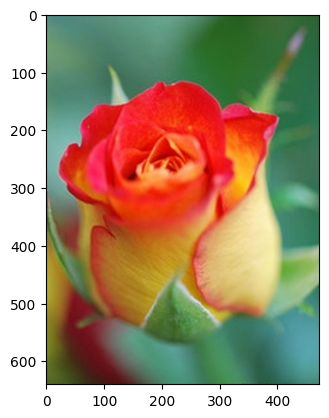

In [5]:
# look at an image for fun
plt.imshow(image.load_img('Food-5K/training/0_808.jpg'))
plt.show()

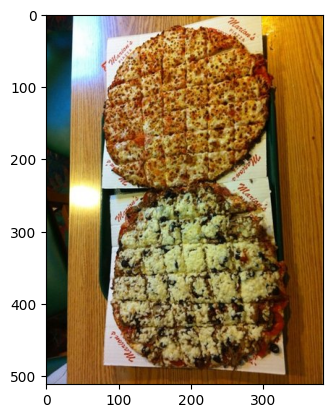

In [6]:
# Food images start with 1, non-food images start with 0
plt.imshow(image.load_img('Food-5K/training/1_616.jpg'))
plt.show()

In [7]:
!mkdir Food-5K/data


mkdir: cannot create directory ‘Food-5K/data’: File exists


In [8]:
!mkdir Food-5K/data/train
!mkdir Food-5K/data/test
!mkdir Food-5K/data/train/nonfood
!mkdir Food-5K/data/train/food
!mkdir Food-5K/data/test/nonfood
!mkdir Food-5K/data/test/food

mkdir: cannot create directory ‘Food-5K/data/train’: File exists
mkdir: cannot create directory ‘Food-5K/data/test’: File exists
mkdir: cannot create directory ‘Food-5K/data/train/nonfood’: File exists
mkdir: cannot create directory ‘Food-5K/data/train/food’: File exists
mkdir: cannot create directory ‘Food-5K/data/test/nonfood’: File exists
mkdir: cannot create directory ‘Food-5K/data/test/food’: File exists


In [9]:
# Move the images
# Note: we will consider 'training' to be the train set
#       'validation' folder will be the test set
#       ignore the 'evaluation' set
!mv Food-5K/training/0*.jpg Food-5K/data/train/nonfood
!mv Food-5K/training/1*.jpg Food-5K/data/train/food
!mv Food-5K/validation/0*.jpg Food-5K/data/test/nonfood
!mv Food-5K/validation/1*.jpg Food-5K/data/test/food

In [10]:
!rm -r Food-5K/training Food-5K/validation Food-5K/evaluation

In [11]:
train_path = 'Food-5K/data/train'
valid_path = 'Food-5K/data/test'

In [12]:
# These images are pretty big and of different sizes
# Let's load them all in as the same (smaller) size
IMAGE_SIZE = [200, 200]

In [13]:
# useful for getting number of files
image_files = glob(train_path + '/*/*.jpg')
valid_image_files = glob(valid_path + '/*/*.jpg')

In [14]:
# useful for getting number of classes
folders = glob(train_path + '/*')
folders

['Food-5K/data/train/food', 'Food-5K/data/train/nonfood']

In [15]:
K = len(folders)
K

2

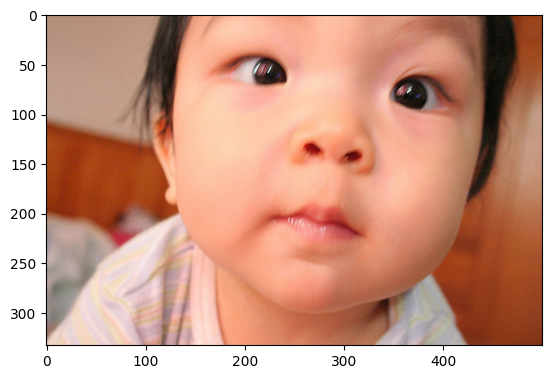

In [16]:
# look at an image for fun
plt.imshow(image.load_img(np.random.choice(image_files)))
plt.show()

In [17]:
ptm = PretrainedModel(
    input_shape=IMAGE_SIZE + [3],
    weights='imagenet',
    include_top=False)

I0000 00:00:1769997399.290283  288449 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3881 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:01:00.0, compute capability: 7.5


In [18]:
# freeze pretrained model weights
ptm.trainable = False

In [19]:
# data augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

In [20]:
# Build the model using the functional API
i = Input(shape=IMAGE_SIZE + [3])
x = preprocess_input(i)
x = data_augmentation(x)
x = ptm(x)
x = Flatten()(x)
# x = Dense(8192, activation='relu')(x)
# x = Dense(4096, activation='relu')(x)
# x = Dense(2048, activation='relu')(x)
# x = Dense(1024, activation='relu')(x)
# x = Dense(512, activation='relu')(x)
# x = Dense(256, activation='relu')(x)
# x = Dense(128, activation='relu')(x)
# x = Dense(64, activation='relu')(x)
# x = Dense(32, activation='relu')(x)
x = Dense(K, activation='softmax')(x)
model = Model(inputs=i, outputs=x)

In [21]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 200, 200)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 200, 200)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 200, 200)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 200, 200,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 200, 200,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 200, 200,  │          0 │ add[0][0]         │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16 (Functional)  │ (None, 6, 6, 512) │ 14,714,688 │ sequential[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 18432)     │          0 │ vgg16[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │     36,866 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 14,751,554 (56.27 MB)

 Trainable params: 36,866 (144.01 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [22]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [23]:
batch_size = 128

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=IMAGE_SIZE,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    image_size=IMAGE_SIZE,
    batch_size=batch_size
)

Found 3000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.


In [24]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [25]:
# fit the model
r = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10


2026-02-02 06:56:42.415766: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801
2026-02-02 06:56:42.693274: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.89GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-02 06:56:42.745135: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.24GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
W0000 00:00:1769997402.745151  289073 gpu_utils.cc:68] Failed to allocate memory for convolution redzone checking; skipping this check. This is benign and only means that we won't check cudnn for out-of-bounds reads and writes. This message will only b

 9/24 ━━━━━━━━━━━━━━━━━━━━ 7s 483ms/step - accuracy: 0.7605 - loss: 2.9501

2026-02-02 06:56:57.218761: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.76GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-02 06:56:57.654936: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 3.79GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-02-02 06:56:58.796763: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.94GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


24/24 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.9250 - loss: 1.1585 - val_accuracy: 0.9790 - val_loss: 0.5341
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 632ms/step - accuracy: 0.9753 - loss: 0.5146 - val_accuracy: 0.9760 - val_loss: 0.4990
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 634ms/step - accuracy: 0.9840 - loss: 0.2581 - val_accuracy: 0.9700 - val_loss: 0.7351
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 631ms/step - accuracy: 0.9887 - loss: 0.1833 - val_accuracy: 0.9760 - val_loss: 0.5058
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 630ms/step - accuracy: 0.9863 - loss: 0.1897 - val_accuracy: 0.9780 - val_loss: 0.4820
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 628ms/step - accuracy: 0.9900 - loss: 0.1679 - val_accuracy: 0.9780 - val_loss: 0.5325
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 628ms/step - accuracy: 0.9903 - loss: 0.1200 - val_accuracy: 0.9780 - val_loss: 0.6808
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 15s 636ms/step - accuracy: 0.9910 - loss: 0.0939 - val_accuracy: 0.9810 -

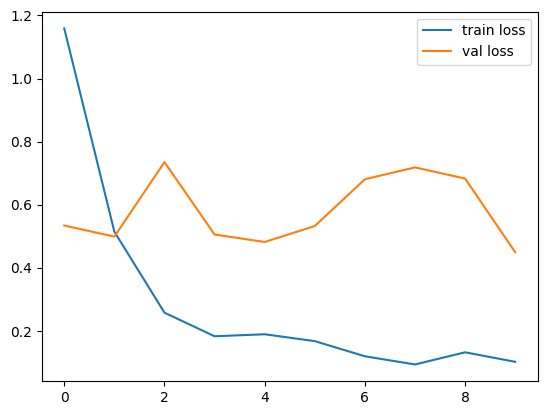

In [26]:
# loss
plt.plot(r.history['loss'], label='train loss')
plt.plot(r.history['val_loss'], label='val loss')
plt.legend()
plt.show()

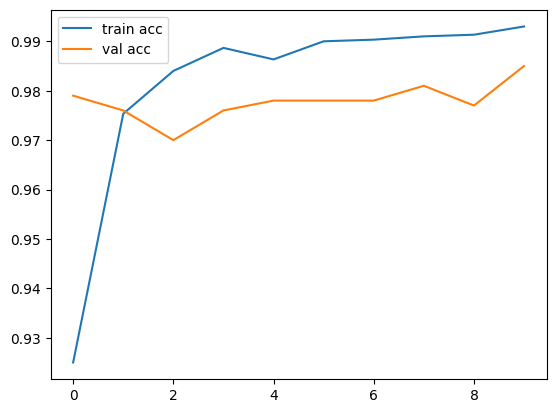

In [27]:
# accuracies
plt.plot(r.history['accuracy'], label='train acc')
plt.plot(r.history['val_accuracy'], label='val acc')
plt.legend()
plt.show()